In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import numpy as np
import random

from tqdm import tqdm
from IPython.display import clear_output

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [2]:
TRAJECTORY_LEN = 1001
STATE_DIM = 29
# FEATURES_TO_CONSIDER = [0, 1, 15, 16]
FEATURES_TO_CONSIDER = torch.arange(29)

KEEP_ONLY_COORDS = True

In [3]:
def reset_to_location(env, location):
    env.sim.reset()
    qpos = env.init_qpos + env.np_random.uniform(low=-.1, high=.1, size=env.model.nq)
    qpos[:2] = np.array(location).astype(env.observation_space.dtype)
    qvel = env.init_qvel + env.np_random.randn(env.model.nv) * .1
    env.set_state(qpos, qvel)
    return env.unwrapped._get_obs()

In [4]:
import gym
import d4rl # Import required to register environments, you may need to also import the submodule

# Create the environment
env = gym.make('antmaze-large-diverse-v2')
dataset = env.get_dataset()

/home/nazim/.local/lib/python3.10/site-packages/gym/wrappers/monitoring/video_recorder.py:9: DeprecationWarning: The distutils package is deprecated and slated for removal in Python 3.12. Use setuptools or check PEP 632 for potential alternatives
  import distutils.spawn
/home/nazim/.local/lib/python3.10/site-packages/mujoco_py/builder.py:9: DeprecationWarning: The distutils.sysconfig module is deprecated, use sysconfig instead
  from distutils.sysconfig import customize_compiler
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead
No module named 'flow'
No module named 'carla'
pybullet build time: Jan 29 2025 23:16:28
/home/nazim/.local/lib/python3.10/site-packages/gym/spaces/box.py:84: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Target Goal:  (32.249842332534314, 25.30455476876921)


load datafile: 100%|██████████| 8/8 [00:01<00:00,  5.32it/s]


In [189]:
dataset_trajectories = torch.tensor(dataset['observations'])
dataset_trajectories = dataset_trajectories[..., :STATE_DIM]
# dataset_trajectories = torch.concatenate((dataset_trajectories[..., [0, 1]], dataset_trajectories[..., [15, 16]]), dim=-1)

dataset_actions = torch.tensor(dataset['actions'])
dataset_terminals = torch.tensor(dataset['terminals'])
dataset_timeouts = torch.tensor(dataset['timeouts'])

dataset_goals = torch.tensor(dataset['infos/goal'])



# [:999*1001]

dataset_trajectories = dataset_trajectories[:999*1001].reshape(-1, 1001, STATE_DIM)
dataset_actions = dataset_actions[:999*1001].reshape(-1, 1001, 8)
dataset_terminals = dataset_terminals[:999*1001]
dataset_timeouts = dataset_timeouts[:999*1001].reshape(-1, 1001)


num_trajectories, len_trajectory, obs_dim = dataset_trajectories.shape

In [6]:
dataset_mean = dataset_trajectories.mean([0, 1])
dataset_std = dataset_trajectories.std([0, 1])


def normalize_dataset_coords(dataset_, features_to_consider_only=False):
    return dataset_
    is_numpy = isinstance(dataset_, np.ndarray)
    if is_numpy: dataset_ = torch.tensor(dataset_)
    dataset = dataset_.clone()
    if not features_to_consider_only:
        dataset = (dataset - dataset_mean) / dataset_std
    else:
        dataset = (dataset - dataset_mean[FEATURES_TO_CONSIDER]) / dataset_std[FEATURES_TO_CONSIDER]
    if is_numpy: dataset = np.array(dataset.cpu())
    return dataset

def denormalize_dataset_coords(dataset_, features_to_consider_only=False):
    return dataset_
    is_numpy = isinstance(dataset_, np.ndarray)
    if is_numpy: dataset_ = torch.tensor(dataset_)
    dataset = dataset_.clone()
    if not features_to_consider_only:
        dataset = dataset * dataset_std + dataset_mean
    else:
        dataset = dataset * dataset_std[FEATURES_TO_CONSIDER] + dataset_mean[FEATURES_TO_CONSIDER]
    if is_numpy: dataset = np.array(dataset.cpu())
    return dataset

dataset_trajectories = normalize_dataset_coords(dataset_trajectories)
dataset_trajectories_cuda = dataset_trajectories.to(device)


In [7]:
import torch
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Create a long enough PEs tensor
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # (1, max_len, d_model) so it can be broadcast over batch
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (batch_size, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]  # match seq_len
        return self.dropout(x)


In [8]:
class FRENetwork(nn.Module):
    def __init__(self, state_dim, action_dim, num_heads=2, num_layers=2, d_model=128):
        super().__init__()
        
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.d_model = d_model
        self.num_discrete_embeddings = 32
        
        self.encoder_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                self.d_model, 
                num_heads, 
                dim_feedforward=4*self.d_model, 
                batch_first=True
            ),
            num_layers=num_layers
        )
        self.encoder_mean = nn.Linear(self.d_model, self.d_model)
        self.encoder_log_std = nn.Linear(self.d_model, self.d_model)

        self.state_embed = nn.Linear(self.state_dim, self.d_model // 2)
        self.action_embed = nn.Linear(self.action_dim, self.d_model // 2)

        self.action_predict = nn.Sequential(
            nn.Linear(self.state_dim + self.d_model, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, action_dim),
            nn.Tanh()
        )
        
        self.positional_encoding = PositionalEncoding(d_model=d_model, dropout=0.1, max_len=200)



    def get_transformer_encoding(self, states, actions, pad_mask):  
        
        batch_size, num_anchors = states.shape[0], states.shape[1]
        
        if pad_mask is None:
            pad_mask = torch.zeros((batch_size, num_anchors), dtype=torch.bool, device=states.device)
        # pad_mask.shape = [batch, anchors]
                
        state_emb = self.state_embed(states)
        action_emb = self.action_embed(actions)
        
        state_action_emb = torch.concat([state_emb, action_emb], dim=-1)
        
        x = self.positional_encoding(state_action_emb)
        w_pre = self.encoder_transformer(x, src_key_padding_mask=pad_mask) # [batch, anchors, emb_dim]
        
        
        valid_tokens = (~pad_mask).float()  # (B, T), converts True -> 0, False -> 1
        valid_tokens = valid_tokens.unsqueeze(-1)  # (B, T, 1)
        sum_embeddings = (w_pre * valid_tokens).sum(dim=1)  # Sum over sequence dimension
        w_pair_mean = sum_embeddings / valid_tokens.sum(dim=1)
        
        # w_pair_mean = w_pre.mean(axis=1)
        # print(w_pair_mean.shape)
        w_mean = self.encoder_mean(w_pair_mean)
        w_log_std = self.encoder_log_std(w_pair_mean)

        return w_mean, w_log_std # (batch_size, emb_dim)
    
    
    def get_action_pred(self, w, states): # Reward Pairs: [batch, seq, obs_dim]
        z_expand = w.unsqueeze(1) # [batch, 1, emb_dim]
        z_expand = z_expand.repeat(1, states.shape[1], 1)        
        
        w_and_obs = torch.concatenate([z_expand, states], axis=-1)
        
        reward_pred = self.action_predict(w_and_obs)
        
        return reward_pred # [batch, reward_pairs]
        

# FRE:

In [9]:
class MLPRewards:
    def __init__(self, N, obs_len):

        self.N = N
        
        self.param_w1 = torch.normal(0, 1, size=(self.N, obs_len, 32)) * np.sqrt(1/32)
        self.param_b1 = torch.normal(0, 1, size=(self.N, 1, 32)) * np.sqrt(16)
        self.param_w2 = torch.normal(0, 1, size=(self.N, 32, 1)) * np.sqrt(1/16)
    
    def sample(self, N):
        return torch.randint(0, self.N, (N,))

    def __call__(self, obs, param_id=None):
        """
        obs.shape = (batch_size, num_samples, obs_dim)
        param_id.shape = (batch_size, 1)
        """
        
        batch_size, num_samples, obs_dim = obs.shape
        batch_size_, _ = param_id.shape
        assert (batch_size == batch_size_)
        
        device = obs.device
        
        if param_id is None:
            param_id = torch.randint(0, self.N, size=(obs.shape[0], 1))
        
        param_id_expanded = param_id.repeat(1, obs.shape[1]).cpu()
        param1_w = self.param_w1[param_id_expanded].to(device)
        param1_b = self.param_b1[param_id_expanded].to(device)
        param2_w = self.param_w2[param_id_expanded].to(device)

        # obs[..., 2:] = 0.0
        
        x = torch.unsqueeze(obs, -2) # [batch, (pairs), 1, features_in]
        x = torch.matmul(x, param1_w) # [batch, (pairs), 1, features_out]
        x = x + param1_b
        x = torch.tanh(x)
        r = torch.matmul(x, param2_w) # [batch, (pairs), 1, 1]
        r = r.squeeze(-1).squeeze(-1) # [batch, (pairs)]
        r = torch.clip(r, -1, 1)

        return r, param_id
    
# mlp_rewards = MLPRewards(N=10000, obs_len=29)

In [10]:
class LinearRewards:
    def __init__(self, N, obs_len):

        self.N = N
        
        self.param_w1 = torch.rand(size=(self.N, obs_len, 1)) * 2 - 1
        self.random_mask = torch.rand(size=(self.N, obs_len)) < 0.9
        self.random_mask[..., :2] = True
        
        random_mask_positive = np.random.randint(2, obs_len, size=(N,))
        self.random_mask[np.arange(N), random_mask_positive] = False # Force at least one positive weight.
        

    def sample(self, N):
        return torch.randint(0, self.N, (N,))

    def __call__(self, obs, param_id=None):
        """
        obs.shape = (batch_size, num_samples, obs_dim)
        param_id.shape = (batch_size, 1)
        """
        
        batch_size, num_samples, obs_dim = obs.shape
        batch_size_, _ = param_id.shape
        assert (batch_size == batch_size_)
        
        device = obs.device
        
        if param_id is None:
            param_id = torch.randint(0, self.N, size=(obs.shape[0], 1))
        
        param_id_expanded = param_id.repeat(1, obs.shape[1]).cpu()
        param1_w = self.param_w1[param_id_expanded].to(device)
        mask = self.random_mask[param_id_expanded].to(device)
        obs = (~mask) * obs
        
        x = torch.unsqueeze(obs, -2) # [batch, (pairs), 1, features_in]
        r = torch.matmul(x, param1_w) # [batch, (pairs), 1, features_out]
        r = r.squeeze(-1).squeeze(-1) # [batch, (pairs)]
        r = torch.clip(r, -1, 1)

        return r, param_id

In [11]:
class GoalRewards:
    def __init__(self):
        pass
    
    def sample_goals(self, N):
        goals = dataset_trajectories[
            torch.randint(0, num_trajectories, (N,)),
            torch.randint(0, len_trajectory, (N,)),
        ]
        return goals
    
    # def get_states(self, num_states, goals):
    #     cond = (dataset_trajectories[..., :2] - goal[..., :2]).norm(dim=-1) < 0.5
    #     dataset_trajectories_cuda[cond][torch.randint(0, cond.sum(), (1,))]
    
    def __call__(self, obs, goals=None):
        """
        obs.shape = (batch_size, num_samples, obs_dim)
        param.shape = (batch_size, obs_dim)
        """
        batch_size, num_samples, obs_dim = obs.shape
        batch_size_, obs_dim_ = goals.shape
        assert (batch_size == batch_size_) and (obs_dim == obs_dim_)
        
        device = obs.device
        
        goals = goals.to(device)

        # r = torch.norm(obs - goals.unsqueeze(-2), dim=-1) < 2
        r = torch.norm(obs[..., :2] - goals[..., :2].unsqueeze(-2), dim=-1) < 2
        r = r.float() * 2 - 1
        r = torch.clip(r, -1, 1)

        return r, goals


In [12]:
linear_rewards = LinearRewards(N=10000, obs_len=29)
mlp_rewards = MLPRewards(N=10000, obs_len=29)
goal_rewards = GoalRewards()

In [13]:
def sample_reward_function_fre(batch_size, num_random_samples):

    trajectories_idx = torch.randint(0, num_trajectories, (batch_size*num_random_samples,))
    states_idx = torch.randint(0, len_trajectory, (batch_size*num_random_samples,))
    random_states = dataset_trajectories[trajectories_idx, states_idx] # get the random states
    random_states = random_states.reshape(batch_size, num_random_samples, len(FEATURES_TO_CONSIDER)).to(device)

    reward_latent = torch.zeros((batch_size, 128))
    random_states_rewards = torch.zeros((batch_size, num_random_samples))

    for b in range(batch_size):
        reward_type = torch.randint(0, 3, (1,)) # 0: goal_reaching | 1: linear_reward | 2: mlp_reward
        
        reward_latent[b, 0] = reward_type
        if reward_type == 0:
            goal = goal_rewards.sample_goals(1)
            goal = goal.repeat(1, 1)
            r, param_id = goal_rewards(random_states[[b]], goals=goal)    
            reward_latent[b, 1:1+obs_dim] = param_id
            random_states[b, 0] = goal
            r[0, 0] = 1.
            
        elif reward_type == 1:
            param_id = linear_rewards.sample(1).unsqueeze(0)
            r, param_id = linear_rewards(random_states[[b]], param_id)
            reward_latent[b, 1] = param_id
            
        elif reward_type == 2:
            param_id = mlp_rewards.sample(1).unsqueeze(0)
            r, param_id = mlp_rewards(random_states[[b]], param_id) 
            reward_latent[b, 1] = param_id
            
        random_states_rewards[b] = r
        
    return reward_latent, random_states, random_states_rewards

In [14]:
# reward_latent, random_states, random_states_rewards = sample_reward_function_fre(batch_size=16, num_random_samples=200)

# for b in range(16):
#     # plt.scatter(dataset_trajectories[:, ::10, 0], dataset_trajectories[:, ::10, 1])
#     plt.scatter(random_states[b, :, 0].cpu(), random_states[b, :, 1].cpu(), c=random_states_rewards[b], vmin=-1, vmax=1)
#     plt.show()

# FRE:

In [15]:
class FRENetwork(nn.Module):
    def __init__(self, obs_len, num_heads=2, num_layers=2, reward_pairs_emb_dim=128):
        super().__init__()
        
        self.obs_len = obs_len
        self.reward_pairs_emb_dim = reward_pairs_emb_dim
        self.num_discrete_embeddings = 32
        
        self.encoder_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                self.reward_pairs_emb_dim, 
                num_heads, 
                dim_feedforward=4*self.reward_pairs_emb_dim, 
                batch_first=True
            ),
            num_layers=num_layers
        )
        self.encoder_mean = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)
        self.encoder_log_std = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)

        self.reward_embed = nn.Embedding(self.num_discrete_embeddings, self.reward_pairs_emb_dim // 2)
        self.state_embed = nn.Linear(self.obs_len, self.reward_pairs_emb_dim // 2)

        self.reward_predict = nn.Sequential(
            nn.Linear(self.obs_len + self.reward_pairs_emb_dim, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 1),
        )


    def get_transformer_encoding(self, reward_state_pairs):
        reward_states = reward_state_pairs[:, :, :-1]
        reward_values = reward_state_pairs[:, :, -1]
        reward_values_idx = torch.floor((reward_values / 2.0 + 0.5) * self.num_discrete_embeddings).int()
        reward_values_idx = torch.clip(reward_values_idx, 0, self.num_discrete_embeddings - 1)

        
        reward_state_emb = self.state_embed(reward_states)
        reward_state_val = self.reward_embed(reward_values_idx)
        
        reward_state_pairs = torch.concatenate([reward_state_emb, reward_state_val], axis=-1)

        w_pre = self.encoder_transformer(reward_state_pairs) # [batch, reward_pairs, emb_dim]
        
        w_pair_mean = w_pre.mean(axis=1)
        # print(w_pair_mean.shape)
        w_mean = self.encoder_mean(w_pair_mean)
        w_log_std = self.encoder_log_std(w_pair_mean)

        return w_mean, w_log_std # (batch_size, emb_dim)
    
    
    def get_reward_pred(self, w, reward_states): # Reward Pairs: [batch, reward_pairs, obs_dim + 1]
        z_expand = w.unsqueeze(1) # [batch, 1, emb_dim]
        z_expand = z_expand.repeat(1, reward_states.shape[1], 1)        
        
        w_and_obs = torch.concatenate([z_expand, reward_states], axis=-1)
        
        reward_pred = self.reward_predict(w_and_obs)
        
        return reward_pred # [batch, reward_pairs]
        

In [16]:
fre_network = FRENetwork(obs_len=obs_dim).to(device)
optimimizer = torch.optim.Adam(fre_network.parameters(), lr=0.001)

reward_losses = []
kl_losses = []

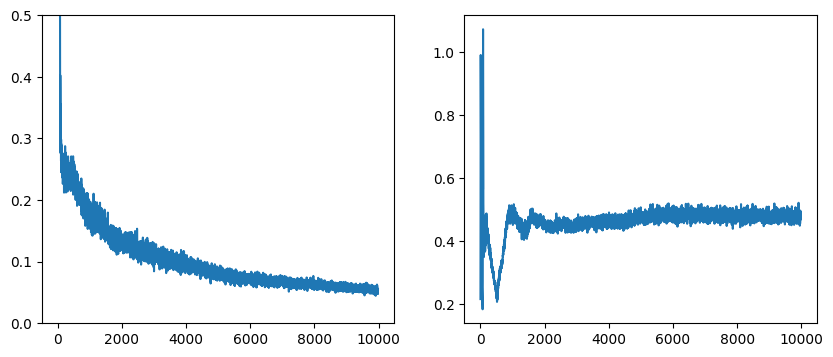

100%|██████████| 10000/10000 [27:29<00:00,  6.06it/s]


In [17]:
num_encode_states = 128
num_decode_states = 128

for i in tqdm(range(10_000)):
    
    reward_latent, random_states, random_states_rewards = sample_reward_function_fre(batch_size=256, num_random_samples=(num_encode_states+num_decode_states))
    
    encode_obs = random_states[:, :num_encode_states, :].to(device)
    decode_obs = random_states[:, num_encode_states:, :].to(device)
    
    encode_rewards = random_states_rewards[:, :num_encode_states, None].to(device)
    decode_rewards = random_states_rewards[:, num_encode_states:, None].to(device)

            
    # encode_rewards, goals = goal_rewards(encode_obs, goals=None)
    # decode_rewards, goals = goal_rewards(decode_obs, goals=goals)
    
    reward_state_pairs = torch.concatenate((encode_obs, encode_rewards), axis=-1)
    
    w_mean, w_log_std = fre_network.get_transformer_encoding(reward_state_pairs)
    
    
    # Calculate the loss:
    
    w = w_mean + torch.normal(0, 1, size=w_mean.shape, device=device) * torch.exp(w_log_std)
    # w = w_mean
    rewards_pred = fre_network.get_reward_pred(w, decode_obs)
    
    reward_pred_loss = ((rewards_pred - decode_rewards)**2).mean()
    kl_loss = -0.5 * (1 + w_log_std - w_mean**2 - torch.exp(w_log_std)).mean()
    loss = reward_pred_loss + kl_loss * 0.01
    
    optimimizer.zero_grad()
    loss.backward()
    optimimizer.step()
    
    reward_losses.append(reward_pred_loss.item())
    kl_losses.append(kl_loss.item())
    
    if i % 20 == 0:
        clear_output(True)
        fig, axs = plt.subplots(1, 2, figsize=(10, 4))
        axs[0].plot(reward_losses)
        # axs[0].set_xscale('log')
        axs[0].set_ylim(0, 0.5)
        axs[1].plot(kl_losses)
        plt.show()
        


In [76]:
# torch.save(fre_network.state_dict(), 'models/offline_fre-fre_network.pth')

In [93]:
from utils.antmaze_benchmark import VelocityRewardFunction, SimplexRewardFunction, TestRewPath, TestRewLoop, TestRewMatrixEdges, goal_reaching_reward

velocity_reward_function = VelocityRewardFunction()
simplex_reward_function = SimplexRewardFunction(num_simplex=10)

benchmarks = [
    (goal_reaching_reward, 'goal_bottom', np.array([28, 0])),
    (goal_reaching_reward, 'goal_left', np.array([0, 15])),
    (goal_reaching_reward, 'goal_top', np.array([35, 24])),
    (goal_reaching_reward, 'goal_center', np.array([12, 24])), 
    (goal_reaching_reward, 'goal_right', np.array([33, 16])),
    (velocity_reward_function.compute_reward, 'vel_left', [-1, 0]),
    (velocity_reward_function.compute_reward, 'vel_up', [0, 1]),
    (velocity_reward_function.compute_reward, 'vel_down', [0, -1]),
    (velocity_reward_function.compute_reward, 'vel_right', [1, 0]),
    (simplex_reward_function.compute_reward, 'simplex_1', 1),
    (simplex_reward_function.compute_reward, 'simplex_2', 2),
    (simplex_reward_function.compute_reward, 'simplex_3', 3),
    (simplex_reward_function.compute_reward, 'simplex_4', 4),
    (simplex_reward_function.compute_reward, 'simplex_5', 5),
    (TestRewPath().compute_reward, 'path_center', None),
    (TestRewLoop().compute_reward, 'path_loop', None),
    (TestRewMatrixEdges().compute_reward, 'path_edges', None)
]

Generating simplex seeds


100%|██████████| 10/10 [00:00<00:00, 23.46it/s]


In [98]:

test_reward_function, _, _ = benchmarks[-1]

In [104]:
test_reward_function(encode_obs.cpu()).unsqueeze(-1).shape, encode_rewards.shape

(torch.Size([1, 128, 1]), torch.Size([1, 128, 1]))

In [355]:
num_eval_states = 10_000

reward_latent, random_states, random_states_rewards = sample_reward_function_fre(batch_size=1, num_random_samples=(128+num_eval_states))

encode_obs = random_states[:, :128, :].to(device)
decode_obs = random_states[:, 128:, :].to(device)

encode_rewards = random_states_rewards[:, :128, None].to(device)
decode_rewards = random_states_rewards[:, 128:, None].to(device)

# benchmark_id = 0
# encode_rewards = benchmarks[benchmark_id][0](encode_obs.cpu(), np.array([0, 15])).unsqueeze(-1).to(device)
# decode_rewards = benchmarks[benchmark_id][0](decode_obs.cpu(), np.array([0, 15])).unsqueeze(-1).to(device)

        
# encode_rewards, goals = goal_rewards(encode_obs, goals=None)
# decode_rewards, goals = goal_rewards(decode_obs, goals=goals)

reward_state_pairs = torch.concatenate((encode_obs, encode_rewards), axis=-1)

with torch.no_grad():
    w_mean, w_log_std = fre_network.get_transformer_encoding(reward_state_pairs)

    # Calculate the loss:

    w = w_mean + torch.normal(0, 1, size=w_mean.shape, device=device) * torch.exp(w_log_std)
    # w = w_mean
    
    rewards_pred = fre_network.get_reward_pred(w, decode_obs)

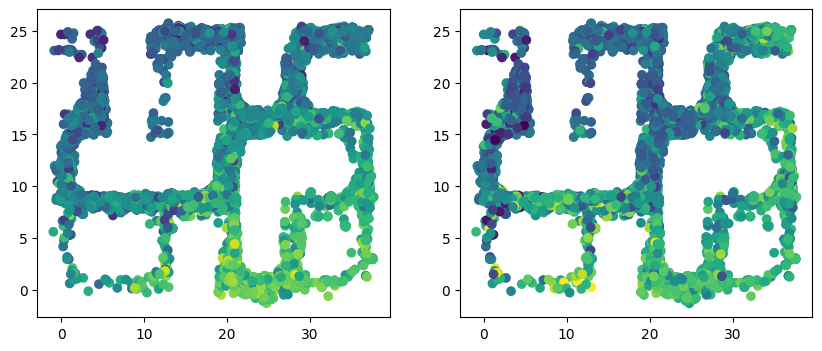

In [168]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].scatter(decode_obs[..., 0].cpu(), decode_obs[..., 1].cpu(), c=rewards_pred.cpu())
axs[1].scatter(decode_obs[..., 0].cpu(), decode_obs[..., 1].cpu(), c=decode_rewards.cpu())

# IQL:

In [195]:
import torch
import torch.nn as nn

class MLP(nn.Module):
    """Generic MLP with Mish activation and LayerNorm."""
    def __init__(self, input_dim, hidden_dims, output_dim):
        super().__init__()
        layers = []
        prev_dim = input_dim

        # Add hidden layers with Mish activation and LayerNorm
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.Mish())
            # layers.append(nn.LayerNorm(hidden_dim))
            prev_dim = hidden_dim  # Update input size for next layer
        
        # Final output layer
        layers.append(nn.Linear(prev_dim, output_dim))

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


class ValueCritic(nn.Module):
    def __init__(self, obs_dim, hidden_dims):
        super().__init__()
        self.model = MLP(obs_dim, hidden_dims, output_dim=1)

    def forward(self, x):
        return self.model(x)


class Critic(nn.Module):
    def __init__(self, obs_dim, action_dim, hidden_dims):
        super().__init__()

        self.model1 = MLP(obs_dim + action_dim, hidden_dims, output_dim=1)
        self.model2 = MLP(obs_dim + action_dim, hidden_dims, output_dim=1)

    def forward(self, x, action):
        x = torch.cat((x, action), dim=-1)
        
        q1 = self.model1(x)
        q2 = self.model2(x)
        
        return q1, q2



class Actor(nn.Module):
    def __init__(self, input_dim, action_dim, hidden_dims, init_std=0.0):
        super().__init__()
        self.model = MLP(input_dim, hidden_dims, output_dim=action_dim)  # MLP only predicts mean
        
        # Learnable log standard deviation (initialized to `init_std`)
        self.log_std = nn.Parameter(torch.ones(action_dim) * init_std)

    def forward(self, x, temperature=1.0):
        mean = self.model(x)  # Predict action mean

        log_std = torch.clip(self.log_std, -20, 2)
        mean = torch.clip(mean, -5, 5)

        return torch.distributions.Normal(
            mean, 
            torch.exp(log_std)*temperature
        )


from torch.optim.lr_scheduler import CosineAnnealingLR

class IQL(nn.Module):
    def __init__(self, state_dim, action_dim, w_dim=128):
        super(IQL, self).__init__()
        self.obs_len = state_dim
                
        self.critic = Critic(w_dim + state_dim, action_dim, hidden_dims=[512, 512, 512, 512])
        self.target_critic = Critic(w_dim + state_dim, action_dim, hidden_dims=[512, 512, 512, 512])
        
        self.value = ValueCritic(w_dim + state_dim, hidden_dims=[512, 512, 512, 512])        
        self.actor = Actor(w_dim + state_dim, action_dim, hidden_dims=[512, 512, 512, 512])
        
        self.critic_optim = torch.optim.Adam(self.critic.parameters(), lr=0.003)
        self.value_optim = torch.optim.Adam(self.value.parameters(), lr=0.003)
        self.actor_optim = torch.optim.Adam(self.actor.parameters(), lr=0.003)
        self.actor_lr_schedule = CosineAnnealingLR(self.actor_optim, 1_000_000)
        
        
    def get_value(self, w, obs):
        w_and_obs = torch.concatenate([w, obs], dim=-1)
        return self.value(w_and_obs)

    def get_critic(self, w, obs, actions):
        w_and_obs = torch.concatenate([w, obs], dim=-1)
        return self.critic(w_and_obs, actions)
    
    def get_target_critic(self, w, obs, actions):
        w_and_obs = torch.concatenate([w, obs], dim=-1)
        return self.critic(w_and_obs, actions)

    def get_actor(self, w, obs, temperature=1.0):
        w_and_obs = torch.concatenate([w, obs], dim=-1)
        return self.actor(w_and_obs, temperature)
    
    
    
def update_target_critic(critic, target_critic, tau):

    critic_state_dict = critic.state_dict()
    target_critic_state_dict = target_critic.state_dict()

    for key in critic_state_dict:
        target_critic_state_dict[key] = tau * critic_state_dict[key] + (1 - tau) * target_critic_state_dict[key]

    target_critic.load_state_dict(target_critic_state_dict)
    
    
def expectile_loss(adv, diff, expectile=0.7):
    weight = torch.where(
        adv >= 0, 
        torch.tensor(expectile, dtype=adv.dtype), 
        torch.tensor(1 - expectile, dtype=adv.dtype)
    )
    return weight * (diff ** 2)


def smooth_and_downsample(losses, smoothing=0.9, max_points=100):
    if not losses: return []
    smoothed = [losses[0]]
    for loss in losses[1:]:
        smoothed.append(smoothing * smoothed[-1] + (1 - smoothing) * loss)
    downsample = max(1, len(smoothed) // max_points)  # Ensure at least 1
    return smoothed[::downsample]

In [211]:
def get_iql_training_data(batch_size, num_states):

    trajectory_idx = torch.randint(0, num_trajectories, (batch_size*num_states,))
    state_idx = torch.randint(0, len_trajectory, (batch_size*num_states,)) % 1000

    states = dataset_trajectories[trajectory_idx, state_idx].reshape(batch_size, num_states, obs_dim)
    next_states = dataset_trajectories[trajectory_idx, state_idx+1].reshape(batch_size, num_states, obs_dim)
    actions = dataset_actions[trajectory_idx, state_idx].reshape(batch_size, num_states, 8)
    masks = ~dataset_timeouts[trajectory_idx, state_idx+1].reshape(batch_size, num_states, 1)
    
    return {
        'states': states.to(device),
        'actions': actions.to(device),
        'next_states': next_states.to(device),
        'masks': masks.to(device),
    }

In [423]:
iql_agent = IQL(state_dim=obs_dim, action_dim=8).to(device)

actor_losses = []
v_losses, q_losses = [], []
mse_errors = []
stds = []

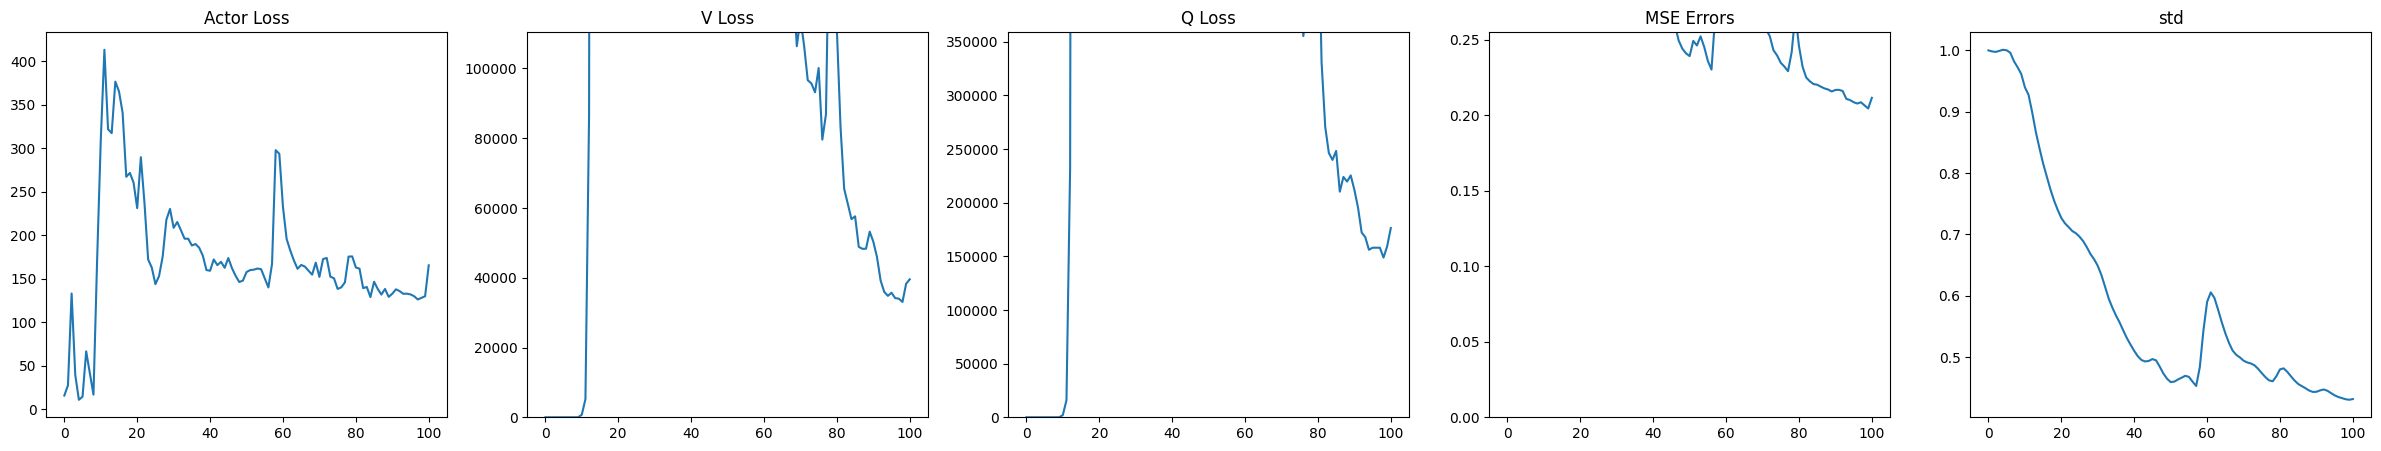

  0%|          | 200/100000 [00:41<5:47:47,  4.78it/s]


KeyboardInterrupt: 

In [451]:
config = {
    'expectile': 0.8,
    'temperature': 3.0,
    'discount': 0.99,
    'tau': 0.001,
}

iql_batch_size = 32
iql_num_states = 512


for timestep in tqdm(range(100_000)):

    
    reward_latent, random_states, random_states_rewards = sample_reward_function_fre(batch_size=iql_batch_size, num_random_samples=128)
    encode_obs = random_states[:, :128, :].to(device)
    encode_rewards = random_states_rewards[:, :128, None].to(device)
    reward_state_pairs = torch.concatenate((encode_obs, encode_rewards), axis=-1)
    
    
    batch = get_iql_training_data(
        batch_size=iql_batch_size, 
        num_states=iql_num_states
    )
    
    with torch.no_grad():
        w_mean, _ = fre_network.get_transformer_encoding(reward_state_pairs)   
        batch['rewards'] = fre_network.get_reward_pred(w_mean, batch['states'])

        

    # Implicit Q-Learning
    w_target = w_mean.unsqueeze(1).repeat(1, batch['states'].shape[1], 1)
    
    with torch.no_grad():
        
        target_q1, target_q2 = iql_agent.get_target_critic(w_target, batch['states'], batch['actions'])
        target_q1, target_q2 = target_q1.detach(), target_q2.detach()
        target_q = torch.minimum(target_q1, target_q2)
        next_v = iql_agent.get_value(w_target, batch['next_states']).detach()
    
    
    # Value Loss: Update V towards expectile of min(q1, q2).
    
    v = iql_agent.get_value(w_target, batch['states'])
    adv = target_q - v
    v_loss = expectile_loss(adv, target_q - v, config['expectile'])
    v_loss = v_loss.mean()

    iql_agent.value.zero_grad()
    v_loss.backward()
    iql_agent.value_optim.step()

    # Critic Loss. Update Q = r #############################
    targets = batch['rewards'] + config['discount'] * batch['masks'] * next_v

    q1, q2 = iql_agent.get_critic(w_target, batch['states'], batch['actions'])
    q_loss = ((q1 - targets) ** 2 + (q2 - targets) ** 2) / 2
    q_loss = q_loss.mean()
    
    iql_agent.critic.zero_grad()
    q_loss.backward()
    iql_agent.critic_optim.step()

    update_target_critic(iql_agent.critic, iql_agent.target_critic, config['tau'])

    value_loss = v_loss + q_loss
    value_info = {
        'v_loss': v_loss,
        'q_loss': q_loss,
        'v': v.mean(),
        'q': torch.minimum(q1, q2).mean(),
    }


    # Actor Loss ############################################


    v = iql_agent.get_value(w_target, batch['states']).detach()
    q1, q2 = iql_agent.get_critic(w_target, batch['states'], batch['actions'])
    q1, q2 = q1.detach(), q2.detach()
    q = torch.minimum(q1, q2)
    adv = q - v

    actions = batch['actions']
    exp_a = torch.exp(adv * config['temperature'])
    exp_a = torch.minimum(exp_a, torch.tensor(100.0))
    # exp_a = torch.ones_like(exp_a)
    
    dist = iql_agent.get_actor(w_target, batch['states'])
    # log_probs = dist.log_prob(actions)
    log_probs = dist.log_prob(actions).sum(axis=-1, keepdim=True)
    assert exp_a.shape == log_probs.shape
    # print("Log probs shape", log_probs.shape)
    actor_loss = -(exp_a * log_probs).mean()

    std = dist.stddev.mean()
    mse_error = ((dist.loc - batch['actions'])**2).mean()
    
    # diff = ((dist.loc - batch['actions'])**2).sum(-1, keepdim=True)
    # actor_loss = (exp_a * diff).mean()
    
    iql_agent.actor.zero_grad()
    actor_loss.backward()
    iql_agent.actor_optim.step()
    # iql_agent.actor_lr_schedule.step()
    
    actor_info = {
        'actor_loss': actor_loss,
        'std': std,
        'adv': adv.mean(),
        'mse_error': mse_error,
    }

    ########################################################################################
    
    # loss = value_loss + actor_loss
    
    # optimizer.zero_grad()
    # loss.backward()
    # optimizer.step()

    
    
    
    actor_losses.append(actor_loss.item())
    v_losses.append(v_loss.item())
    q_losses.append(q_loss.item())
    mse_errors.append(mse_error.item())
    stds.append(std.item())
    
    if timestep % 100 == 0:
        clear_output(True)
        fig, axs = plt.subplots(1, 5, figsize=(30, 5))
        axs[0].plot(smooth_and_downsample(actor_losses))
        # axs[0].set_ylim(0,50)
        axs[0].set_title("Actor Loss")
        
        axs[1].plot(smooth_and_downsample(v_losses))
        axs[1].set_ylim(0,max(v_losses[-100:]))
        axs[1].set_title("V Loss")
        
        axs[2].plot(smooth_and_downsample(q_losses))
        axs[2].set_ylim(0,max(q_losses[-100:]))
        axs[2].set_title("Q Loss")
        
        axs[3].plot(smooth_and_downsample(mse_errors))
        axs[3].set_ylim(0,max(mse_errors[-100:]))
        axs[3].set_title("MSE Errors")
        
        axs[4].plot(smooth_and_downsample(stds))
        axs[4].set_title("std")

        plt.show()
        
    # break

# Benchmark:

In [452]:
import matplotlib.patches as patches


def add_largest_maze_walls(ax):    

    maze_optim = [
        (1, 1, 1, 2),    
        (0, 4, 2, 1),
        (3, 1, 1, 4),
        (5, 0, 1, 1),
        (4, 2, 3, 1),
        (1, 6, 3, 1),
        (4, 4, 2, 1),
        (5, 6, 2, 1),
        (1, 8, 1, 1),
        (3, 7, 1, 2),
        (5, 8, 1, 2)
    ]

    block_size = 0.025 * 80

    height, width = 7, 10
    torso_x, torso_y = (width - 1)*block_size, (height - 1)*block_size

    rects = []
    for i in range(len(maze_optim)):
        (y, x, w, h) = maze_optim[i]
            
        x = x * block_size * 2 - torso_x + (h - 1) * block_size - h * block_size + 18
        y = y * block_size * 2 - torso_y + (w - 1) * block_size - w * block_size + 12
        h, w = h * block_size * 2, w * block_size * 2
        w = w * 1.
        y = y * 1.
        rect = patches.Rectangle((x, y), h, w, linewidth=2, edgecolor='gray', facecolor='gray')

        ax.add_patch(rect)
        
        
        
def get_eval_rewards(eval_z, to_keep:list=None): 
    states = dataset_trajectories[0:300, :1000:10].reshape(-1, obs_dim)
    states = states.to(device)

    res = []
    for i in range(len(eval_z)):
        
        zi = eval_z[i].unsqueeze(0)
        with torch.no_grad():
            x = states.unsqueeze(0)
            if to_keep is not None:
                x = torch.zeros_like(x)
                x[..., to_keep] = states[..., to_keep]
            r = fre_network.get_reward_pred(zi, x).cpu()
            
            res.append(r)
    
    res = torch.stack(res).squeeze(-1)
    
    return x.cpu(), res.cpu()

In [456]:
def run_test(benchmark_id, num_evals, num_eval_anchors):


    benchmark_reward_function, benchmark_test_label, benchmark_param = benchmarks[benchmark_id]


    reward_latent, random_states, random_states_rewards = sample_reward_function_fre(batch_size=1, num_random_samples=num_eval_anchors)
    encode_obs = random_states[:, :128, :].to(device)

    # encode_rewards = random_states_rewards[:, :128, None].to(device)
    # decode_rewards = random_states_rewards[:, 128:, None].to(device)

    benchmark_id = 0
    encode_rewards =benchmark_reward_function(encode_obs.cpu(), benchmark_param).unsqueeze(-1).to(device)
    decode_rewards =benchmark_reward_function(decode_obs.cpu(), benchmark_param).unsqueeze(-1).to(device)

    reward_state_pairs = torch.concatenate((encode_obs, encode_rewards), axis=-1)

    with torch.no_grad():
        w_mean, _ = fre_network.get_transformer_encoding(reward_state_pairs)  
        
        
        
    env.reset()
    # location = np.array(env.unwrapped._wrapped_env._get_reset_location())
    location = (20, 15)
    start_state = reset_to_location(env, location)
    start_state = normalize_dataset_coords(start_state)[..., :]
    state = start_state

    tensor_state = torch.tensor(state).reshape(1, -1).to(device).float() 
    
    
    
    produced_trajectory = []

    for step in tqdm(range(10)):
        
        produced_trajectory.append(state)
        
        with torch.no_grad():
            tensor_state = torch.tensor(state).reshape(1, -1).to(device).float()
            dist = iql_agent.get_actor(w_mean, tensor_state)
            action = dist.loc.cpu()
            action = np.array(action[0]).clip(-1, 1)

            
        new_state, _, _, _ = env.step(action)
        
        state = normalize_dataset_coords(new_state)[..., :]
        
    produced_trajectory = np.stack(produced_trajectory)
    
    return produced_trajectory, w_mean

Target Goal:  (32.95608212038784, 24.546996253443133)


100%|██████████| 10/10 [00:00<00:00, 1111.55it/s]


Target Goal:  (33.211389592559485, 24.690599884986845)


100%|██████████| 10/10 [00:00<00:00, 1099.28it/s]


Target Goal:  (32.75748150555694, 24.572634575005114)


...

100%|██████████| 10/10 [00:00<00:00, 781.15it/s]


Target Goal:  (32.83620029256636, 24.978702386414636)


100%|██████████| 10/10 [00:00<00:00, 661.89it/s]


Target Goal:  (32.31708678350208, 24.17983933328569)


100%|██████████| 10/10 [00:00<00:00, 654.10it/s]


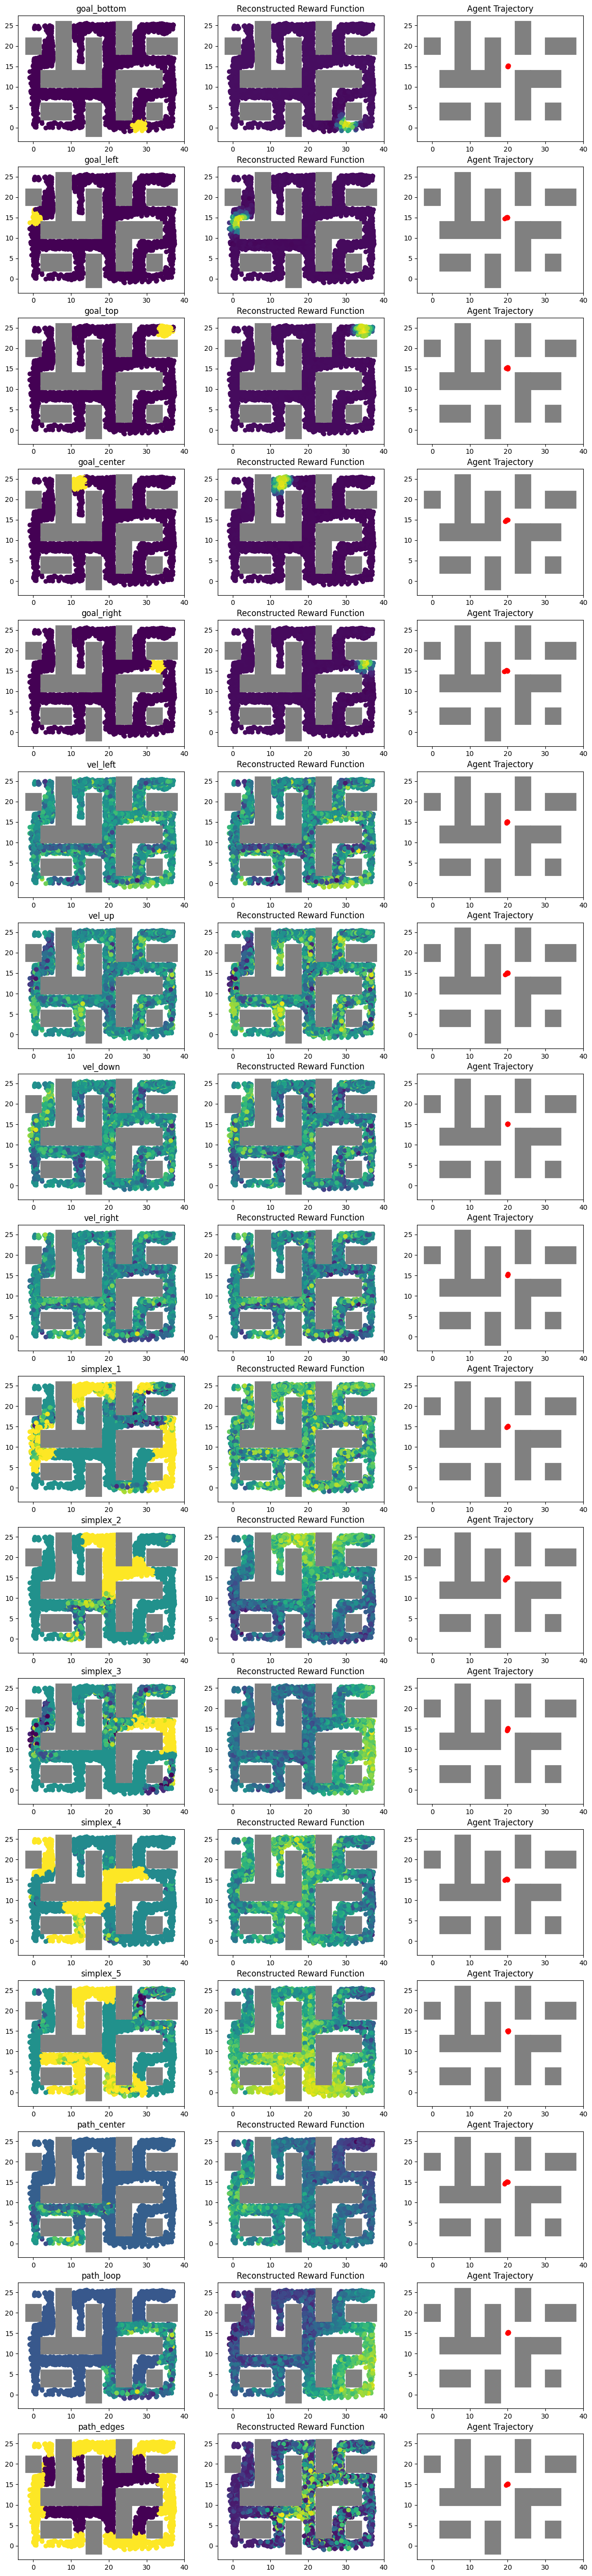

In [457]:
fig, axs = plt.subplots(len(benchmarks), 3, figsize=(15, len(benchmarks)*4))

for benchmark_id in range(len(benchmarks)):

    benchmark_reward_function, benchmark_test_label, benchmark_param = benchmarks[benchmark_id]
    
    produced_trajectory, w_mean = run_test(benchmark_id=benchmark_id, num_evals=1, num_eval_anchors=128)
    

    eval_states, eval_rewards = get_eval_rewards(w_mean)
    real_eval_rewards = benchmark_reward_function(eval_states, benchmark_param)

    axs[benchmark_id, 0].scatter(eval_states[..., 0], eval_states[..., 1], c=real_eval_rewards)
    axs[benchmark_id, 1].scatter(eval_states[..., 0], eval_states[..., 1], c=eval_rewards)
    axs[benchmark_id, 2].scatter(produced_trajectory[:, 0], produced_trajectory[:, 1], c='red')
    
    add_largest_maze_walls(axs[benchmark_id, 0])
    add_largest_maze_walls(axs[benchmark_id, 1])
    add_largest_maze_walls(axs[benchmark_id, 2])
    
    # plt.title(f'{benchmark_test_label}')
    axs[benchmark_id, 0].set_title(f'{benchmark_test_label}')
    axs[benchmark_id, 1].set_title(f'Reconstructed Reward Function')
    axs[benchmark_id, 2].set_title(f'Agent Trajectory')
    
    
plt.show()